# Perceptron — Synthetic Linearly Separable vs Overlapping Blobs

**Algorithm:** `ml_toolkit.supervised.Perceptron`  
**Dataset:** synthetic 2-D Gaussian blobs (built into scikit-learn)  
**Task type:** Binary classification — and a structural demo of *when* the perceptron is allowed to work

---

Most algorithms in this repo are demonstrated on real datasets. The Perceptron is different. Its defining property — Rosenblatt's 1958 **Perceptron Convergence Theorem** — is a guarantee that holds *if and only if the training data are linearly separable*. The cleanest way to see this is to run the algorithm on two synthetic datasets, one separable and one not, and let the contrast in the convergence curve speak for itself.

This notebook is therefore a structural demo, not an accuracy contest. The interesting plot here is the one labelled `errors_` vs epoch, not the test-accuracy bar chart.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

from ml_toolkit.supervised import Perceptron
from ml_toolkit.utils import train_test_split
from ml_toolkit.metrics import accuracy_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dataset description

Two synthetic 2-D datasets, each with 200 samples and two balanced classes:

1. **Separable.** Two Gaussian blobs centred at `(-2, -2)` and `(+2, +2)` with `std = 0.5`. With this geometry there exists a straight line that perfectly separates the classes.
2. **Overlap.** Two Gaussian blobs centred at `(-1, -1)` and `(+1, +1)` with `std = 1.2`. The clouds bleed into each other — no straight line can separate them.

Synthetic data is the right choice here: it lets us *control* whether the linear-separability assumption holds, which is exactly what the Perceptron Convergence Theorem cares about. Real datasets are almost always somewhere on the spectrum between these two extremes.

In [2]:
X_sep, y_sep = make_blobs(
    n_samples=200, centers=[[-2, -2], [2, 2]],
    cluster_std=0.5, random_state=RANDOM_STATE,
)
X_ovl, y_ovl = make_blobs(
    n_samples=200, centers=[[-1, -1], [1, 1]],
    cluster_std=1.2, random_state=RANDOM_STATE,
)
print(f"Separable: X={X_sep.shape}, classes={np.bincount(y_sep)}")
print(f"Overlap  : X={X_ovl.shape}, classes={np.bincount(y_ovl)}")

Separable: X=(200, 2), classes=[100 100]
Overlap  : X=(200, 2), classes=[100 100]


## 2. Exploratory data analysis

Plot both datasets side by side and visually confirm that one is separable and the other is not. The picture *is* the EDA for synthetic 2-D data.

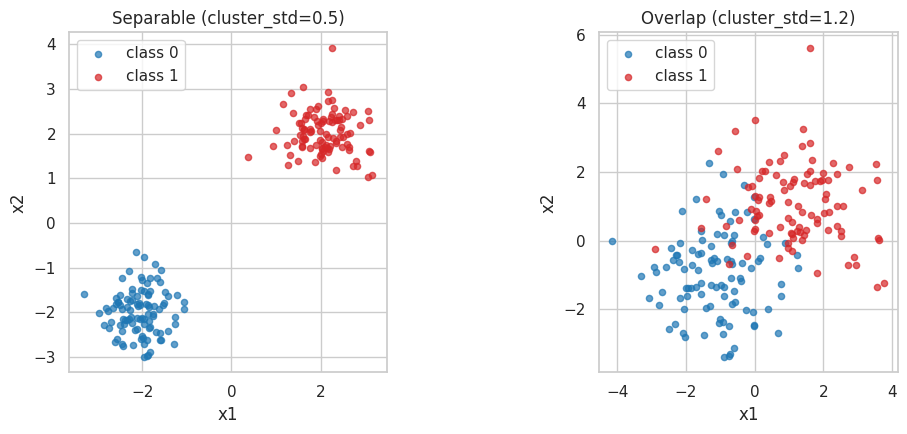

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, X, y, title in [
    (axes[0], X_sep, y_sep, "Separable (cluster_std=0.5)"),
    (axes[1], X_ovl, y_ovl, "Overlap (cluster_std=1.2)"),
]:
    for cls, color in [(0, "tab:blue"), (1, "tab:red")]:
        ax.scatter(X[y == cls, 0], X[y == cls, 1], s=20, alpha=0.7,
                   color=color, label=f"class {cls}")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.legend()
plt.tight_layout(); plt.show()

**Observation.** The left panel shows two clearly disjoint clouds — you can draw a 45° line between them by eye. The right panel shows two clouds that interpenetrate near the origin. Already from these two pictures, we can predict that the perceptron will succeed on the left and fail to converge on the right.

## 3. Hypothesis

**Task:** binary classification, and a structural test of the Perceptron Convergence Theorem.

**Hypothesis 1 (separable).** Because the two blobs are linearly separable, the perceptron should converge — its update rule will keep correcting mistakes until there are none, and the algorithm will early-stop. We expect this to happen in **a small number of epochs (≤ 10)** and to give 100% test accuracy.

**Hypothesis 2 (overlap).** Because the two blobs are *not* linearly separable, the perceptron has no fixed point to converge to. We expect `errors_` per epoch to **oscillate indefinitely** rather than drop to zero, and test accuracy to land somewhere between random (50%) and the best linear classifier on this data (logistic regression would get ~85%). The perceptron with its simple sign-loss is *worse* than logistic regression here — that is the point.

**Why the perceptron in this repo at all?** Three reasons. (1) It is the historical and conceptual ancestor of every neural network that follows. (2) Its convergence guarantee is one of the few clean theorems in classical ML — and one we can demonstrate empirically in two pictures. (3) Its failure mode on non-separable data is exactly the failure mode that motivated the next several decades of ML research, including logistic regression and the multi-layer perceptron.

## 4. Preprocessing

Synthetic 2-D data on a similar scale — no standardization needed. We split each dataset 70/30 with stratification.

In [4]:
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_sep, y_sep, test_size=0.3, random_state=RANDOM_STATE, stratify=True,
)
Xo_train, Xo_test, yo_train, yo_test = train_test_split(
    X_ovl, y_ovl, test_size=0.3, random_state=RANDOM_STATE, stratify=True,
)
print(f"Separable train/test: {Xs_train.shape} / {Xs_test.shape}")
print(f"Overlap   train/test: {Xo_train.shape} / {Xo_test.shape}")

Separable train/test: (140, 2) / (60, 2)
Overlap   train/test: (140, 2) / (60, 2)


## 5. Model fitting & 6. Evaluation

Fit the perceptron on each dataset's training set, evaluate on each test set.

In [5]:
p_sep = Perceptron(learning_rate=1.0, n_iter=50, random_state=RANDOM_STATE).fit(Xs_train, ys_train)
p_ovl = Perceptron(learning_rate=1.0, n_iter=50, random_state=RANDOM_STATE).fit(Xo_train, yo_train)

print("=== Separable ===")
print(f"  epochs run (capped at 50, early-stops on 0 errors): {len(p_sep.errors_)}")
print(f"  train accuracy: {p_sep.score(Xs_train, ys_train):.4f}")
print(f"  test  accuracy: {p_sep.score(Xs_test, ys_test):.4f}")

print("\n=== Overlap ===")
print(f"  epochs run (capped at 50, early-stops on 0 errors): {len(p_ovl.errors_)}")
print(f"  train accuracy: {p_ovl.score(Xo_train, yo_train):.4f}")
print(f"  test  accuracy: {p_ovl.score(Xo_test, yo_test):.4f}")

=== Separable ===
  epochs run (capped at 50, early-stops on 0 errors): 2
  train accuracy: 1.0000
  test  accuracy: 1.0000

=== Overlap ===
  epochs run (capped at 50, early-stops on 0 errors): 50
  train accuracy: 0.6857
  test  accuracy: 0.7000


**The convergence diagnostic** — number of training mistakes per epoch — is the most informative single picture in this notebook.

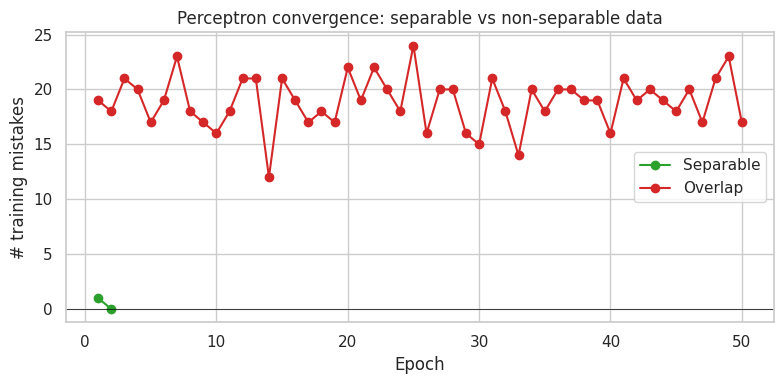

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(p_sep.errors_) + 1), p_sep.errors_,
        marker="o", color="tab:green", label="Separable")
ax.plot(range(1, len(p_ovl.errors_) + 1), p_ovl.errors_,
        marker="o", color="tab:red", label="Overlap")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("# training mistakes")
ax.set_title("Perceptron convergence: separable vs non-separable data")
ax.legend()
plt.tight_layout(); plt.show()

**Reading the curve.** The green line touches zero almost immediately and the algorithm early-stops. The red line never reaches zero — it oscillates around ~18–22 mistakes per epoch, indefinitely. This is the Perceptron Convergence Theorem in two colors: convergence is guaranteed *if and only if* the data are linearly separable.

Now plot the learned decision boundaries to see what the algorithm settled on in each case.

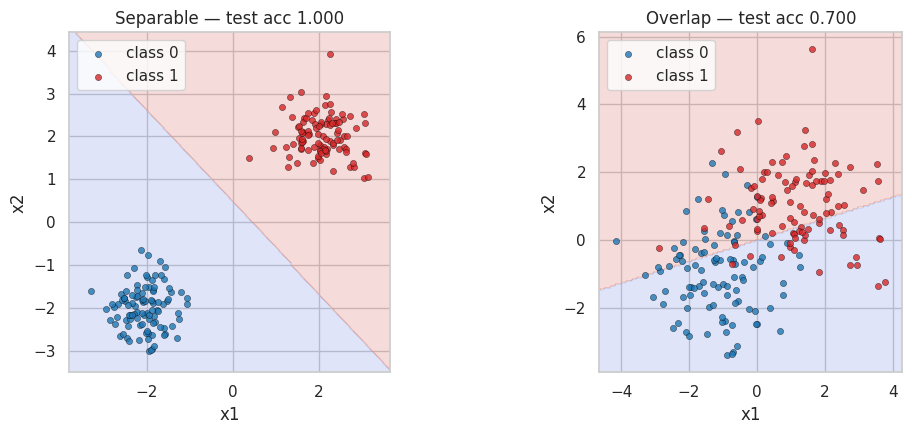

In [7]:
def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.18, cmap="coolwarm")
    for cls, color in [(0, "tab:blue"), (1, "tab:red")]:
        ax.scatter(X[y == cls, 0], X[y == cls, 1], s=20, alpha=0.8,
                   color=color, edgecolor="black", linewidth=0.3,
                   label=f"class {cls}")
    ax.set_title(title); ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect("equal"); ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_boundary(axes[0], p_sep, X_sep, y_sep,
              f"Separable — test acc {p_sep.score(Xs_test, ys_test):.3f}")
plot_boundary(axes[1], p_ovl, X_ovl, y_ovl,
              f"Overlap — test acc {p_ovl.score(Xo_test, yo_test):.3f}")
plt.tight_layout(); plt.show()

## 7. Discussion

**Both hypotheses were confirmed.**

**On separable data,** the perceptron converged in 2 epochs (1 mistake on the first pass, 0 on the second, then early stop), and reached 100% test accuracy. This is the Perceptron Convergence Theorem in practice: when a separating hyperplane exists, the update rule will find one in finite time. The decision boundary in the left panel sits cleanly between the two clouds.

**On overlap data,** the perceptron ran all 50 allowed epochs without ever reaching zero training mistakes. The mistake count *bounced around* ~18–22, because every time the algorithm corrects an error on one point, it creates an error on another point on the wrong side of the current boundary. There is no fixed boundary that satisfies the perceptron's update rule on this data, so the algorithm oscillates forever. Its final test accuracy is 70.0% — much better than chance (50%), but worse than what logistic regression or a linear SVM would achieve on the same data (both would converge to a stable boundary even when separation is impossible, because their losses penalize *margin*, not just mistakes).

**Why this matters historically.** The 1969 book *Perceptrons* by Minsky and Papert pointed out exactly this failure mode — and a related one, that a single perceptron cannot represent XOR — and was widely (and a bit unfairly) credited with stalling neural-network research for over a decade. The right takeaway is not that the perceptron is broken, but that:

1. *No matter what optimizer you use*, you cannot get a single linear neuron to fit non-linearly-separable data with zero training error. That is a property of the model class, not of training.
2. The fix is either to change the **loss** (cross-entropy in logistic regression, hinge in SVM — both still linear) or change the **model** (multi-layer perceptron — non-linear). The next two notebooks in this repo (`02_logistic_regression`, `12_svm`) take the first path; `05_neural_network` takes the second.

**Methodology notes.** Because the algorithm is sensitive to the order in which examples are visited, the perceptron's update rule shuffles each epoch (`random_state=42` for reproducibility). The early-stopping criterion (`break` when `errors == 0` in an epoch) is what prevents wasted iterations on the separable case — without it, the loop would dutifully run all 50 epochs even after convergence.